<h1 style="text-align:center;">Linearity analysis</h1>


*Author* : Gabriel Gattaux

*Date* :  May 2024


## Setup and Imports


In [34]:
import memory
import antcar_sim
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import imutils
import pandas as pd
import plotly
import plotly.graph_objs as go
from scipy.interpolate import griddata
from plotly.subplots import make_subplots
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import subprocess
from scipy.stats import mode,circmean, circvar, circstd
from scipy.sparse import csr_matrix, save_npz, load_npz
from datetime import datetime
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import font_manager
from scipy.stats import pearsonr
from scipy.stats import ttest_rel

# %load_ext autoreload
# %autoreload 2


In [35]:
# List all files and folders in the specified directory

# df = pd.read_csv(dir + 'mapping_parameters.csv')
# print(f'Contents of {item}:')
# print(df)

mapping_447a915f
mapping_77a3e48d
mapping_d051aa51
route_following_in
mapping_fb3cebf2
mapping_f9b48555
mapping_d24a3c66
mapping_090414f3
mapping_02c5f85f
shuttle
route_following_out
mapping_3718f57a
mapping_3d4b8833
mapping_parameters.csv
mapping_70774f67
shuttling_in
mapping_77ca91d6
IN
mapping_b7e40f69
old_temp
mapping_3b73aa2f
mapping_1e0da186
mapping_5a8921df
homing_out
mapping_8423d6e9
homing


In [36]:

# Define the folder where the mappings and the CSV file are located
csv_file_path = '/results/mapping_parameters.csv'
#csv_file_path = '/data/processed/mapping_parameters.csv'

# Read the CSV file
# Read the CSV file
df = pd.read_csv(csv_file_path)
## HEre you need to place the datas downloaded from figshare to the datas folder please
df = df[df["irl_path"] == '/data/raw/images_offline/images_100523_AVM_line_mapping/Expl4']

df = df.sort_values(by=df.columns[11], ascending=True)
print(df)


In [ ]:
## Configure paths and font and graphic display

src_out = "/results/figures/linearity_analysis/"
# Create the directory if it doesn't exist
if not os.path.exists(src_out):
    os.makedirs(src_out)

VERBOSE = False


# Set Seaborn style and context
sns.set_style("white")
sns.set_context("notebook")



## Functions

In [38]:
## Usefuls function to get size of subfolders and reading images
def get_subfolders(folder_path):
    subfolders = []
    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)
        if os.path.isdir(item_path):
            subfolders.append(item)
    return subfolders

# Function to get the real size of an image file on disk
def get_real_file_size(image_path):
    if os.path.exists(image_path):
        return os.path.getsize(image_path)
    else:
        return None

# Function to get the size of a folder and its subdirectories
def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size

def get_first_images_sub(image_processed_path,folder):

    # Define the subdirectories
    # subdirs = ['augmented', 'pns', 'kcs', 'processed']
    subdirs = get_subfolders(os.path.join(image_processed_path,folder))

    # Generate file paths for the first image in each directory
    first_image_paths = {}
    file_sizes = []
    subdir_sizes = []
    dir = []
    images_nbs = []

    for idx,subdir in enumerate(subdirs):
        subdir_path = os.path.join(image_processed_path, folder, subdir)
        files = os.listdir(subdir_path)
        image_files = [file for file in files if file.endswith('.png')]
        lenn = len(image_files)

        # print(lenn)
        if image_files:
            first_image_paths[subdir] = os.path.join(subdir_path, image_files[0])
            file_sizes.append(get_real_file_size(first_image_paths[subdir]))
            subdir_sizes.append(get_folder_size(subdir_path))
            dir.append(folder + '/'+subdir)
            images_nbs.append(lenn)

    # Load the first image of each category using OpenCV
    pn = cv2.imread(first_image_paths.get('pns'), cv2.IMREAD_GRAYSCALE) if 'pns' in first_image_paths else None
    if 'kcs' in first_image_paths:
        kcname = 'kcs'
    else:
        kcname = 'kcs1'
    kc = cv2.imread(first_image_paths.get(kcname), cv2.IMREAD_GRAYSCALE)

    proc = cv2.imread(first_image_paths.get('processed'), cv2.IMREAD_GRAYSCALE) if 'processed' in first_image_paths else None
    normal = cv2.imread(first_image_paths.get('augmented'), cv2.IMREAD_COLOR) if 'augmented' in first_image_paths else None
    normal = cv2.cvtColor(normal, cv2.COLOR_BGR2RGB)

    if pn is not None:
        pn = np.tile(pn, (1, 50))
    else:
        print("No image found for 'pns'")
    
    return pn,kc,proc,normal,np.array(file_sizes),np.array(subdir_sizes),np.array(dir),images_nbs


# Function to convert bytes to human-readable format (KB, MB, GB)
def convert_bytes_to_human_readable(size_in_bytes):
    for unit in ['bytes', 'KB', 'MB', 'GB']:
        if size_in_bytes < 1024.0:
            return f"{size_in_bytes:.2f} {unit}"
        size_in_bytes /= 1024.0

def process_binary_vector_memories(compressed_memory_list, output_file_path):
    """
    Converts binary vector memories to CSR format, saves to disk, calculates file size,
    loads the CSR matrix back, and converts it to a NumPy array.

    Parameters:
    compressed_memory_list (list of list or np.array): The binary vector memories.
    output_file_path (str): The path where the CSR matrix will be saved.

    Returns:
    tuple: A tuple containing the size of the file in bytes and the NumPy array.
    """
    # Convert binary vector memories to CSR format
    csr_binary_vector = csr_matrix(compressed_memory_list)

    # Save CSR matrix to a file
    save_npz(output_file_path, csr_binary_vector)

    # Calculate the size of the saved file
    size_memories = get_real_file_size(output_file_path)

    # Load CSR matrix from the saved file
    loaded_csr_matrix = load_npz(output_file_path)

    # Convert CSR matrix to NumPy array
    numpy_array = loaded_csr_matrix.toarray()

    return size_memories, numpy_array

# Longest Streak of 0s and 1s
def longest_streak(arr, value):
    max_streak = 0
    current_streak = 0
    for i in arr:
        if i == value:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0
    return max_streak

# Entropy
def entropy(arr):
    _, counts = np.unique(arr, return_counts=True)
    probabilities = counts / len(arr)
    return -np.sum(probabilities * np.log2(probabilities))

# Run Length Encoding (RLE)
def run_length_encoding(arr):
    rle = []
    current_run = [arr[0], 1]
    for i in range(1, len(arr)):
        if arr[i] == arr[i - 1]:
            current_run[1] += 1
        else:
            rle.append(tuple(current_run))
            current_run = [arr[i], 1]
    rle.append(tuple(current_run))
    return rle

def compute_unfamiliarity_metrics_on_route(mapping_test_AVM_line, precision_ang):
    # Extract only the mapping data on the learning path (i.e., XTE or d == 0)
    mapping_on_learning_path_df = mapping_test_AVM_line[mapping_test_AVM_line['XTE_truth'] == 0]
    mapping_on_learning_path = mapping_on_learning_path_df.to_numpy()

    # Extract desired states from the on-route mapping
    unfamiliarity_test_learningpath_1 = mapping_on_learning_path[:, 4]
    unfamiliarity_test_learningpath_2 = mapping_on_learning_path[:, 5]
    x_truth_test_learningpath = mapping_on_learning_path[:, 1]
    y_truth_test_learningpath = mapping_on_learning_path[:, 2]
    path_relativ_angle = mapping_on_learning_path[:, 7]

    # Compute Difference, sum, max and relations between unfamiliarities on route columns
    unfamiliarity_onroute_dif_raw = unfamiliarity_test_learningpath_1 - unfamiliarity_test_learningpath_2  # This looks like angular speed
    unfamiliarity_onroute_max_raw = np.maximum(unfamiliarity_test_learningpath_1, unfamiliarity_test_learningpath_2)  # This looks like angular position

    # Reshape the familiarities to be on the same axis 'HE' or 'thetae' for each image (i.e., position) on the path
    unfamiliarity_onroute_1 = unfamiliarity_test_learningpath_1.reshape(-1, (360 // precision_ang) + 1)
    unfamiliarity_onroute_2 = unfamiliarity_test_learningpath_2.reshape(-1, (360 // precision_ang) + 1)

    unfamiliarity_onroute_dif = unfamiliarity_onroute_dif_raw.reshape(-1, (360 // precision_ang) + 1)
    unfamiliarity_onroute_max = unfamiliarity_onroute_max_raw.reshape(-1, (360 // precision_ang) + 1)

    m_arg = np.arange(180, -(180 + precision_ang), -precision_ang)

    # Compute the mean and std according to the 'HE' states for each image
    m_unfa_onroute_1 = np.mean(unfamiliarity_onroute_1, axis=0)
    std_unfa_onroute_1 = np.std(unfamiliarity_onroute_1, axis=0)

    m_unfa_onroute_2 = np.mean(unfamiliarity_onroute_2, axis=0)
    std_unfa_onroute_2 = np.std(unfamiliarity_onroute_2, axis=0)

    m_unfa_onroute_dif = np.mean(unfamiliarity_onroute_dif, axis=0)
    std_unfa_onroute_dif = np.std(unfamiliarity_onroute_dif, axis=0)

    m_unfa_onroute_max = np.mean(unfamiliarity_onroute_max, axis=0)
    std_unfa_onroute_max = np.std(unfamiliarity_onroute_max, axis=0)

    return {
        'm_unfa_onroute_1': m_unfa_onroute_1,
        'std_unfa_onroute_1': std_unfa_onroute_1,
        'm_unfa_onroute_2': m_unfa_onroute_2,
        'std_unfa_onroute_2': std_unfa_onroute_2,
        'm_unfa_onroute_dif': m_unfa_onroute_dif,
        'std_unfa_onroute_dif': std_unfa_onroute_dif,
        'm_unfa_onroute_max': m_unfa_onroute_max,
        'std_unfa_onroute_max': std_unfa_onroute_max,
        'm_unfa_onroute_left': m_unfa_onroute_1,
        'm_unfa_onroute_right': m_unfa_onroute_2,
        'm_arg': np.radians(m_arg),
        'unfamiliarity_onroute_dif':unfamiliarity_onroute_dif,
        'unfamiliarity_onroute_max':unfamiliarity_onroute_max,
        'unfamiliarity_onroute_left':unfamiliarity_onroute_1,
        'unfamiliarity_onroute_right':unfamiliarity_onroute_2
    }

def calculate_pearson_coefficient(m_unfa_onroute_dif, m_arg):
    if len(m_unfa_onroute_dif) != len(m_arg):
        raise ValueError("The length of m_unfa_onroute_dif and m_arg must be the same.")
    correlation, _ = pearsonr(m_unfa_onroute_dif, m_arg)
    return correlation


def calculate_pearson_coefficient_lim(m_unfa_onroute_dif, m_arg, Amp):
    # Filter the values based on Amp
    mask = (m_arg >= -Amp) & (m_arg <= Amp)
    filtered_m_unfa_onroute_dif = m_unfa_onroute_dif[mask]
    filtered_m_arg = m_arg[mask]
    
    # Ensure there are enough values to calculate Pearson correlation
    if len(filtered_m_unfa_onroute_dif) < 2:
        raise ValueError("Not enough data points to calculate Pearson correlation.")
    
    correlation, _ = pearsonr(filtered_m_unfa_onroute_dif, filtered_m_arg)
    return correlation


def read_src(src):
    """
    Acquires and processes the learning and test datasets.

    Parameters:
        src (str): The source directory containing the datasets.

    Returns:
        pd.DataFrame: Processed test dataset.
        pd.DataFrame: Processed learning dataset.
    """
    # Aquire the learning process dataset, the compressed mem and the traj train
    mapping_test_AVM_line = pd.read_csv(f'{src}/mapping_test.csv') 
    mapping_learning_AVM_line = pd.read_csv(f'{src}/mapping_learning.csv') 

    # Define column names
    mapping_test_AVM_line_cols = ['img_index', 'x_truth', 'y_truth', 'theta_truth', 'unfa1', 'unfa2', 'XTE_truth', 'HE_truth']
    mapping_learning_AVM_line_cols = ['img_index1', 'x_truth1', 'y_truth1', 'theta_truth1', 'unfa1_learning', 'kc_sat1',
                                      'img_index2', 'x_truth2', 'y_truth2', 'theta_truth2', 'unfa2_learning', 'kc_sat2']
    
    # Rename columns
    mapping_test_AVM_line = mapping_test_AVM_line.rename(columns=dict(zip(mapping_test_AVM_line.columns, mapping_test_AVM_line_cols)))
    mapping_learning_AVM_line = mapping_learning_AVM_line.rename(columns=dict(zip(mapping_learning_AVM_line.columns, mapping_learning_AVM_line_cols)))
    
    return mapping_test_AVM_line, mapping_learning_AVM_line
            
def tt_lim(x, y,Amp):
    mask = (y >= -Amp) & (y <= Amp)
    x = x[mask]
    y = y[mask]

    t_stat, p_value = ttest_rel(x, y)
    return t_stat, p_value


## Data Loading

In [39]:
from scipy.stats import gaussian_kde, kruskal

precision_ang = 5

amp_values = []
all_m_unfa_dif = np.array([], dtype=float)
all_m_unfa_max = np.array([], dtype=float)
all_m_unfa_right = np.array([], dtype=float)
all_m_unfa_left = np.array([], dtype=float)
all_m_arg = np.array([], dtype=float)
amp_labels = np.array([], dtype=float)
kc_1 = np.array([], dtype=float)
kc_2 = np.array([], dtype=float)
amp_kc = np.array([], dtype=float)
meancorrelation_values = []
meancorrelation_valueslim = []
mean_p_values_sum= []
mean_p_values_simlim = []
iteration_learning = []
spar_means = []
meancorrelation_valueslim_max = []

rotation_secc_rpi = 0.023 #s

for idx, row in df.iterrows():
    corr_sum = 0
    corr_sumlim = 0
    p_value_simlim = 0 
    p_value_sum = 0
    corr_sumlimmax = 0

    path = row['9']
    Amp =  row["5"]
    print(Amp)
    src = ('/results/mapping_' + path)
    ## Aquire the learning process dataset, the compressed mem and the traj train

    mapping_test_AVM_line, mapping_learning_AVM_line = read_src(src)


    results = compute_unfamiliarity_metrics_on_route(mapping_test_AVM_line, precision_ang)
    

    for rotation in results['unfamiliarity_onroute_max']:
        correlation_max_lim = calculate_pearson_coefficient_lim(rotation, np.abs(results['m_arg']), np.radians(Amp))
        corr_sumlimmax = corr_sumlimmax + correlation_max_lim 

    mean_corrlimmax = corr_sumlimmax/len(results['unfamiliarity_onroute_dif'])

    for rotation in results['unfamiliarity_onroute_dif']:
        correlation = calculate_pearson_coefficient(rotation, results['m_arg'])
        correlationlim = calculate_pearson_coefficient_lim(rotation, results['m_arg'],np.radians(Amp))


        t_stat, p_value = ttest_rel(4.2*rotation, results['m_arg'])
        t_statlim, p_valuelim = tt_lim(4.2*rotation, results['m_arg'], np.radians(Amp))
        t_statlim, p_valuelim = kruskal(rotation, results['m_arg'])

        corr_sum = corr_sum + correlation 
        corr_sumlim = corr_sumlim + correlationlim 
        p_value_sum = p_value_sum + p_value
        p_value_simlim  =  p_value_simlim + p_valuelim

    mean_corr = corr_sum/len(results['unfamiliarity_onroute_dif'])
    mean_corrlim = corr_sumlim/len(results['unfamiliarity_onroute_dif'])
    mean_p_value_sum = p_value_sum/len(results['unfamiliarity_onroute_dif'])
    mean_p_value_simlim = p_value_simlim/len(results['unfamiliarity_onroute_dif'])
    mean_spar =  np.mean((mapping_learning_AVM_line['kc_sat1'].min(),mapping_learning_AVM_line['kc_sat2'].min()))


    # Store Amp and correlation values
    amp_values.append(Amp)
    meancorrelation_values.append(mean_corr)
    meancorrelation_valueslim.append(mean_corrlim)
    meancorrelation_valueslim_max.append(mean_corrlimmax)
    mean_p_values_sum.append(mean_p_value_sum)
    mean_p_values_simlim.append(mean_p_value_simlim)
    iteration_learning.append(rotation_secc_rpi * ((Amp*2 / 5) + 1))

    spar_means.append(mean_spar)

    # Store filtered unfamiliarity differences and m_arg for plotting
    # Store unfamiliarity differences and m_arg for plotting
    kc_1 = np.concatenate((kc_1, mapping_learning_AVM_line['kc_sat1']))
    kc_2 = np.concatenate((kc_2, mapping_learning_AVM_line['kc_sat2']))
    amp_kc = np.concatenate((amp_kc, np.full_like(mapping_learning_AVM_line['kc_sat2'], fill_value=Amp)))

    all_m_unfa_dif = np.concatenate((all_m_unfa_dif, results['m_unfa_onroute_dif']))
    all_m_unfa_max = np.concatenate((all_m_unfa_max, results['m_unfa_onroute_max']))
    all_m_unfa_left = np.concatenate((all_m_unfa_left, results['m_unfa_onroute_left']))
    all_m_unfa_right = np.concatenate((all_m_unfa_right, results['m_unfa_onroute_right']))

    all_m_arg = np.concatenate((all_m_arg, results['m_arg']))
    amp_labels = np.concatenate((amp_labels, np.full_like(results['m_arg'], fill_value=Amp)))

    print(Amp,correlation,mean_corr)

# Convert arrays to DataFrame for plotting
plot_data = pd.DataFrame({
    'Amp': amp_labels,
    'm_unfa_dif': all_m_unfa_dif,
    'm_unfa_max': all_m_unfa_max,
    'm_unfa_left': all_m_unfa_left,
    'm_unfa_right': all_m_unfa_right,
    'm_arg': all_m_arg,
})


kc = pd.DataFrame({
    'kc_1':kc_1,
    'kc_2':kc_2,
    'Amp': amp_kc
})


15 0.1332307838946203 0.2905127084406539
30 0.2119052141646791 0.37582963666429076
45 0.25252403348938984 0.4567279216295008
60 0.37290462328101287 0.5659033618958902
75 0.4896153614442938 0.639517651483007
90 0.587473058522217 0.6871184526255448
105 0.7076335522399629 0.744395572161026
120 0.7683830403863939 0.7701060430733433
135 0.7973073949828997 0.785996764703898
150 0.7923135399457205 0.8015372974478154
165 0.782184005714957 0.808165118552984
180 0.7507561043300357 0.7704686623007332


## Data Preprocessing

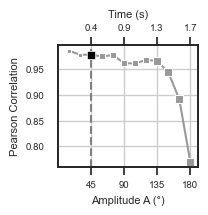

In [42]:
# Convert mm to inches
width_in_inches = 53 / 25.4
height_in_inches = 55 / 25.4

norm = plt.Normalize(min(iteration_learning), max(iteration_learning))
colors = plt.cm.viridis_r(norm(iteration_learning))

# Normalize "Amp" values to range [0, 1]
norm = plt.Normalize(min(amp_values), max(amp_values))
sizes = 3 + norm(amp_values) * (6 - 3)  # Adjust the range as needed for appropriate scaling

# Plot using Seaborn
fig, ax = plt.subplots(figsize=(width_in_inches, height_in_inches))
ax.set_axisbelow(True)

ax.set_xlim([-0.2, 190])
# Create the secondary x-axis on top
ax2 = ax.twiny()

# # Set the same limits as the main x-axis
ax2.set_xlim(ax.get_xlim())

# Set ticks and labels for the secondary x-axis
ax.set_xticks([45,90,135,180])
ax2.set_xticks([45,90,135,180])

ax2.set_xticklabels([f'{iteration_learning[2]:.1f}', f'{iteration_learning[5]:.1f}', f'{iteration_learning[8]:.1f}', f'{iteration_learning[11]:.1f}'])

# Plot lines with markers, with colors based on iteration_learning
for i in range(len(amp_values) - 1):
    # sns.lineplot(ax=ax, x=amp_values[i:i+2], y=meancorrelation_values[i:i+2], color="0.6", marker='o',legend=False,markersize=sizes[i],)
    sns.lineplot(ax=ax, x=amp_values[i:i+2], y=meancorrelation_valueslim[i:i+2], color="0.6", marker='s',legend=False,markersize=sizes[i])
    
sns.scatterplot(ax=ax, x=amp_values[2:3], y=meancorrelation_valueslim[2:3], color="k", marker='s',legend=False,zorder=10)
# sns.scatterplot(ax=ax, x=amp_values[2:3], y=meancorrelation_values[2:3], color="k", marker='o',legend=False,zorder=10)
ax.axvline(x=45, color='0.5', linestyle='--')

# plt.title('Pearson Correlation Coefficient vs. Amp Value')
ax.set_xlabel('Amplitude A (°)')
ax2.set_xlabel('Time (s)')

ax.set_ylabel('Pearson Correlation')
ax.grid(True)
plt.tight_layout()

plt.show()

fig.savefig(src_out+'correlation_coef_LIMIT.svg', format='svg')


In [43]:
plot_data_used = plot_data[plot_data["Amp"]==45]

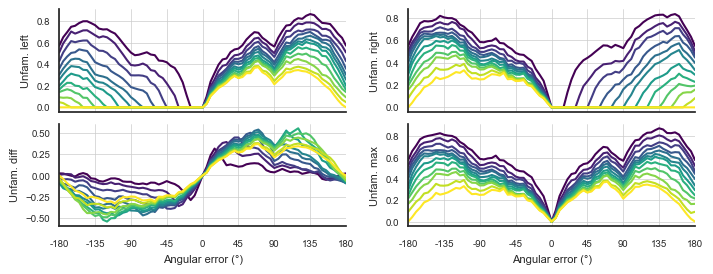

In [60]:

# Convert mm to inches
width_in_inches = 180 / 25.4
height_in_inches = 70 / 25.4

# Create subplots (2x2 grid)
fig, ax = plt.subplots(2, 2, figsize=(width_in_inches, height_in_inches), sharex=True)

columns = ['m_unfa_left', 'm_unfa_right', 'm_unfa_dif', 'm_unfa_max']

# Plot each subplot
for idx, column in enumerate(columns):
    row, col = divmod(idx, 2)  # Get subplot row and column index
    
    # sns.lineplot(ax=ax[row, col], x='m_arg', y=column, size="Amp", sizes=(0.4, 1.2), 
    #              data=plot_data, legend=False, color=".6")
    sns.lineplot(ax=ax[row, col],x='m_arg', y=column, hue='Amp', palette='viridis', legend=False,data=plot_data)
    # sns.lineplot(ax=ax[row, col], x='m_arg', y=column, data=plot_data_used, legend=False, color=".1")

    # Vertical lines at ±45 degrees in radians
    # Set equal aspect ratio and ticks on y-axis
    ax[row, col].tick_params(axis='y', direction='inout')
    ax[row, col].grid(True, linewidth=0.5)  # Adjust grid line width

    
    # Add grid, x-limits, and x-ticks for all subplots
    ax[row, col].grid(True)
    ax[row, col].set_xlim(-np.pi, np.pi)
    ax[row, col].set_xticks([-np.pi, -3*np.pi/4, -2*np.pi/4, -np.pi/4, 0, np.pi/4, 2*np.pi/4, 3*np.pi/4, np.pi])
    ax[row, col].set_xticklabels([-180, -135, -90, -45, 0, 45, 90, 135, 180])
    
    # Set x and y labels for each subplot
    ax[row, col].set_ylabel(column)
# Despine the current axis
    sns.despine(ax=ax[row, col])

# Custom y-axis labels for each subplot
ax[0, 0].set_ylabel("Unfam. left")
ax[0, 1].set_ylabel("Unfam. right")
ax[1, 0].set_ylabel("Unfam. diff")
ax[1, 1].set_ylabel("Unfam. max")

# Set the x-axis label for the bottom subplots
ax[1, 0].set_xlabel("Angular error (°)")
ax[1, 1].set_xlabel("Angular error (°)")

# Despine the current axis
plt.tight_layout()
plt.show()

# Save the figure
fig.savefig(src_out + 'cfamiliaritiesz.svg', format='svg')


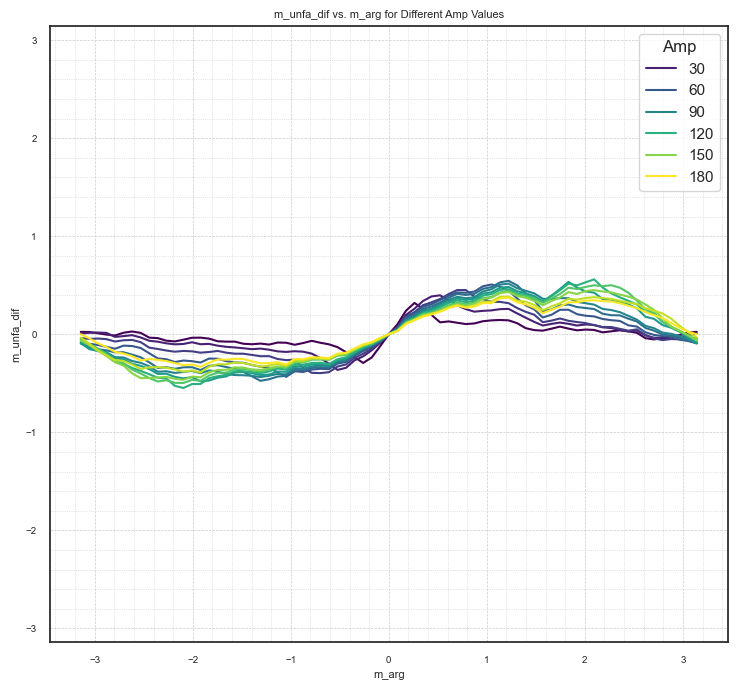

In [45]:

# Plot the m_unfa_dif and m_arg for each Amp using Seaborn
plt.figure(figsize=(14, 8))

sns.lineplot(x='m_arg', y='m_unfa_dif', hue='Amp', palette='viridis', data=plot_data)
plt.ylim(-np.pi, np.pi)
plt.title('m_unfa_dif vs. m_arg for Different Amp Values')
plt.xlabel('m_arg')
plt.ylabel('m_unfa_dif')
plt.legend(title='Amp')

# Set aspect ratio to be equal
plt.gca().set_aspect('equal', adjustable='box')

# Add minor grid lines
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth='0.5')

plt.show()


In [47]:
## Extract only the mapping datas on the learning path (i.e XTE or d == 0)
mapping_on_learning_path_df = mapping_test_AVM_line[mapping_test_AVM_line['XTE_truth'] == 0]
mapping_on_learning_path = mapping_on_learning_path_df.to_numpy()

## Extract desired states from the on-route mapping
unfamiliarity_test_learningpath_1 = mapping_on_learning_path[:,4]
unfamiliarity_test_learningpath_2 = mapping_on_learning_path[:,5]
x_truth_test_learningpath = mapping_on_learning_path[:,1]
y_truth_test_learningpath = mapping_on_learning_path[:,2]
path_relativ_angle = mapping_on_learning_path[:,7]

## Compute Difference, sum, max and relations between unfamilaities on route columns
unfamiliarity_onroute_dif_raw = unfamiliarity_test_learningpath_1  - unfamiliarity_test_learningpath_2## This look like angular speed
unfamiliarity_onroute_max_raw = np.maximum(unfamiliarity_test_learningpath_1,unfamiliarity_test_learningpath_2) ## This lokk like angular position

## Reshape the familiarities to be on the same axe 'HE' or 'thetae' for each images (i.e position) on the path 
unfamiliarity_onroute_1 = unfamiliarity_test_learningpath_1.reshape(-1, (360//precision_ang)+1)
unfamiliarity_onroute_2 = unfamiliarity_test_learningpath_2.reshape(-1, (360//precision_ang)+1)

unfamiliarity_onroute_dif = unfamiliarity_onroute_dif_raw.reshape(-1, (360//precision_ang) +1)
unfamiliarity_onroute_max = unfamiliarity_onroute_max_raw.reshape(-1, (360//precision_ang) +1)


m_arg = np.arange(180,-(180+precision_ang),-precision_ang)

## Compute the mean and std according to the 'HE' states for each images
m_unfa_onroute_1 = np.mean(unfamiliarity_onroute_1,axis=0) ; std_unfa_onroute_1 = np.std(unfamiliarity_onroute_1,axis=0)
m_unfa_onroute_2 = np.mean(unfamiliarity_onroute_2,axis=0) ; std_unfa_onroute_2 = np.std(unfamiliarity_onroute_2,axis=0)

m_unfa_onroute_dif = np.mean(unfamiliarity_onroute_dif,axis=0) ; std_unfa_onroute_dif = np.std(unfamiliarity_onroute_dif,axis=0)
m_unfa_onroute_max = np.mean(unfamiliarity_onroute_max,axis=0) ; std_unfa_onroute_max = np.std(unfamiliarity_onroute_max,axis=0)


In [48]:
# print(mapping_on_learning_path_df)
new_mapping_on_learning_path_df = mapping_on_learning_path_df[["unfa1","unfa2","HE_truth"]].copy()
new_mapping_on_learning_path_df = new_mapping_on_learning_path_df[abs(new_mapping_on_learning_path_df["HE_truth"]) <= 50]
new_mapping_on_learning_path_df["dif"]=(new_mapping_on_learning_path_df["unfa1"] - new_mapping_on_learning_path_df["unfa2"])*180/np.pi


## Exploratory Data Analysis (EDA)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


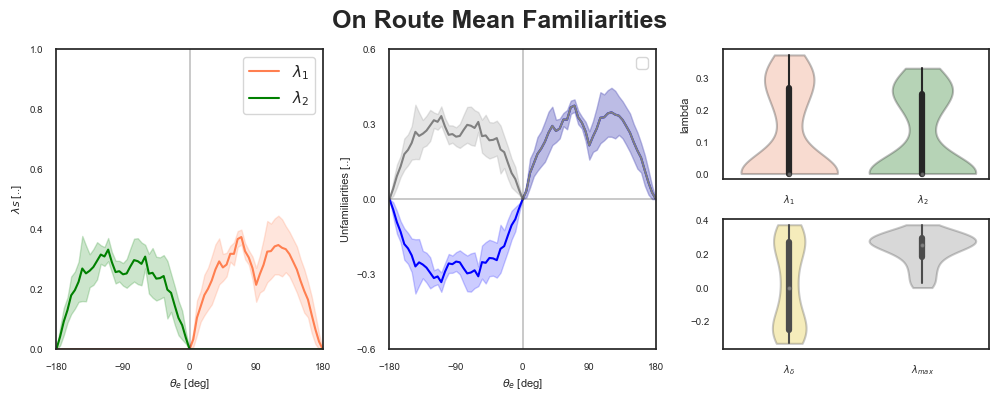

In [49]:
# Define colors and limits
colors = {
    'dif': 'gold',
    'max': 'gray',
    'unfa_1': 'coral',
    'unfa_2': 'green'
}

lim_unfas = [0, 1]
lim_difs = [-0.6, 0.6]

# Create a figure and GridSpec
fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(2, 3)
# , width_ratios=[2, 1, 1]
fig.tight_layout
fig.suptitle('On Route Mean Familiarities', fontsize=18, fontweight='bold')

# Subplot 1: Span the first row and first column
ax1 = fig.add_subplot(gs[:, 0])
for unfa, std_unfa, color, label in zip([m_unfa_onroute_1, m_unfa_onroute_2], [std_unfa_onroute_1, std_unfa_onroute_2], [colors['unfa_1'], colors['unfa_2']], ["$\lambda_1$","$\lambda_2$"]):
    ax1.plot(m_arg, unfa, color=color, label=label)
    ax1.fill_between(m_arg, unfa - std_unfa, unfa + std_unfa, alpha=0.2, color=color)
ax1.set_xlabel("$\\theta_e$ [deg]")
ax1.set_ylabel("$\lambda s$ [..]")
ax1.set_ylim(lim_unfas)
ax1.set_xticks(np.arange(-180, 181, 90))
ax1.legend(loc="upper right")
ax1.set_xlim([-180,180])
ax1.axvline(x=0, color='black', linestyle='-',linewidth=0.3)

ax2 = fig.add_subplot(gs[:, 1])
# Plot segments above zero
ax2.plot(m_arg, m_unfa_onroute_dif, color='blue')
ax2.fill_between(m_arg, m_unfa_onroute_dif - std_unfa_onroute_dif, m_unfa_onroute_dif + std_unfa_onroute_dif, alpha=0.2, color="blue")

ax2.plot(m_arg, m_unfa_onroute_max, color='gray')
ax2.fill_between(m_arg, m_unfa_onroute_max - std_unfa_onroute_max, m_unfa_onroute_max + std_unfa_onroute_max, alpha=0.2, color="gray")

# # Plot segments below zero
# ax2.plot(m_arg[below_zero], data[below_zero], color=color_below, label=label if color_below == 'gold' else "")
# ax2.fill_between(m_arg[below_zero], data[below_zero] - std[below_zero], data[below_zero] + std[below_zero], alpha=0.2, color=color_below)

ax2.set_ylim(lim_difs)
ax2.set_xlim([-180, 180])
ax2.set_xticks(np.arange(-180, 181, 90))
ax2.set_yticks(np.arange(-0.6, 0.7, 0.3))

ax2.set_xlabel("$\\theta_e$ [deg]")
ax2.set_ylabel("Unfamiliarities [..]")
ax2.legend(loc="upper right")
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.3)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.3)



# Subplot 3: Span the first row and third column
ax3 = fig.add_subplot(gs[0, 2])
sns.violinplot(data=[m_unfa_onroute_1, m_unfa_onroute_2], ax=ax3, bw_adjust=0.001, cut=0, palette=[colors['unfa_1'], colors['unfa_2']])
plt.setp(ax3.collections, alpha=.3)
ax3.set_xticklabels(["$\lambda_1$", "$\lambda_2$"])
ax3.set_ylabel("lambda")

# Subplot 4: Span the second row and second and third columns
ax4 = fig.add_subplot(gs[1, 2])
sns.violinplot(data=[m_unfa_onroute_dif, m_unfa_onroute_max], ax=ax4, bw_adjust=0.001, cut=0, palette=[colors['dif'], colors['max']], common_norm=True)
plt.setp(ax4.collections, alpha=.3)
ax4.set_xticklabels(["$\lambda_{\delta}$", "$\lambda_{max}$"])

# Adjust layout
plt.tight_layout()

plt.show()

fig.savefig(src_out+'on_route_mean_familiarities.svg', format='svg')

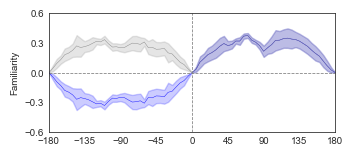

In [ ]:

# Convert mm to inches
width_in_inches = 90 / 25.4
height_in_inches = 40 / 25.4
line_width_points = 0.2 / 25.4 * 72
inner_line_width_points = 0.2 / 25.4 * 72

# Plotting
fig = plt.figure(figsize=(width_in_inches, height_in_inches))
plt.plot(m_arg, m_unfa_onroute_dif, color='blue', linewidth=0.30)
plt.fill_between(m_arg, m_unfa_onroute_dif - std_unfa_onroute_dif, m_unfa_onroute_dif + std_unfa_onroute_dif, alpha=0.2, color="blue")

plt.plot(m_arg, m_unfa_onroute_max, color='gray', linewidth=0.30)
plt.fill_between(m_arg, m_unfa_onroute_max - std_unfa_onroute_max, m_unfa_onroute_max + std_unfa_onroute_max, alpha=0.2, color="gray")

# Customize ticks
plt.xlim(-180, 180)  # Set the x-axis limits from -180 to 180
# plt.xticks(np.arange(-180, 181, 60), [])  # Setting ticks from -180 to 180 with 60-degree intervals, but no labels
plt.xticks(np.arange(-180, 181, 45), fontname='Arial', fontsize=7)

# plt.yticks(np.arange(-0.6, 0.6, 0.3), [])  # Setting ticks from -180 to 180 with 60-degree intervals, but no labels
plt.yticks(np.arange(-0.6, 0.61, 0.3), fontname='Arial', fontsize=7)

plt.tick_params(axis='x', direction='in', length=5, width=line_width_points)  # Ticks on the inside, width 0.3 mm
plt.tick_params(axis='y', direction='in', length=5, width=line_width_points)  # Y-axis ticks on the inside, width 0.3 mm

# Customize axes
ax = plt.gca()
ax.spines['top'].set_linewidth(line_width_points)
ax.spines['bottom'].set_linewidth(line_width_points)
ax.spines['left'].set_linewidth(line_width_points)
ax.spines['right'].set_linewidth(line_width_points)

# Add small gray lines at y=0 and x=0
plt.axhline(0, color='gray', linewidth=line_width_points, linestyle='--')
plt.axvline(0, color='gray', linewidth=line_width_points, linestyle='--')

# Axis labels
# plt.xlabel('Angle (degrees)')
plt.ylabel('Familiarity', fontname='Arial', fontsize=7)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()
fig.savefig(src_out+'on_route_mean.svg', format='svg')


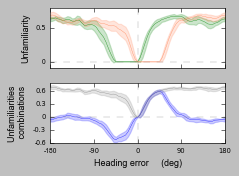

In [ ]:
plt.style.use('classic')
# Convert mm to inches
width_in_inches = 80 / 25.4
height_in_inches = 60 / 25.4

# Create the figure with two polar subplots
fig, axes = plt.subplots(2,1, figsize=(width_in_inches, height_in_inches))

# Plot data for the first set
axes[0].plot(m_arg, m_unfa_onroute_1, color='green', label='$\lambda_1$',linewidth=0.3)
axes[0].fill_between(m_arg, m_unfa_onroute_1 - std_unfa_onroute_1, m_unfa_onroute_1 + std_unfa_onroute_1, alpha=0.2, color='green')
# Plot data for the second set
axes[0].plot(m_arg, m_unfa_onroute_2, color='#ff7f50ff', label='$\lambda_2$',linewidth=0.3)
axes[0].fill_between(m_arg, m_unfa_onroute_2 - std_unfa_onroute_2, m_unfa_onroute_2 + std_unfa_onroute_2, alpha=0.2, color='#ff7f50ff')


axes[1].plot(m_arg, m_unfa_onroute_dif, color='blue', linewidth=0.30)
axes[1].fill_between(m_arg, m_unfa_onroute_dif - std_unfa_onroute_dif, m_unfa_onroute_dif + std_unfa_onroute_dif, alpha=0.2, color="blue")
axes[1].plot(m_arg, m_unfa_onroute_max, color='gray', linewidth=0.30)
axes[1].fill_between(m_arg, m_unfa_onroute_max - std_unfa_onroute_max, m_unfa_onroute_max + std_unfa_onroute_max, alpha=0.2, color="gray")

# Customize ticks
axes[0].set_xlim(-180, 180)
axes[0].set_xticks([-180,-90,0,90,180])
axes[0].set_xticklabels([], fontproperties=prop, fontsize=6)

axes[1].set_xlim(-180, 180)
axes[1].set_xticks([-180,-90,0,90,180])
axes[1].set_xticklabels([-180,-90,0,90,180], fontproperties=prop, fontsize=6)


axes[1].set_yticks([-0.6,-0.3,0,0.3,0.6])
axes[1].set_yticklabels([-0.6,-0.3,0,0.3,0.6], fontproperties=prop, fontsize=6)

axes[0].set_yticks([0,0.5])
axes[0].set_yticklabels([0,0.5], fontproperties=prop, fontsize=6)

# Add small gray lines at y=0 and x=0
axes[0].axhline(0, color='gray', linewidth=inner_line_width_points, linestyle='--')
axes[0].axvline(0, color='gray', linewidth=inner_line_width_points, linestyle='--')
axes[1].axhline(0, color='gray', linewidth=inner_line_width_points, linestyle='--')
axes[1].axvline(0, color='gray', linewidth=inner_line_width_points, linestyle='--')

# Axis labels
axes[1].set_ylabel('Unfamiliarities \n combinations', fontproperties=prop, fontsize=8)
axes[1].set_xlabel('Heading error     (deg)', fontproperties=prop, fontsize=8)
axes[0].set_ylabel('Unfamiliarity', fontproperties=prop, fontsize=8)

# Modify the width of the spines
axes[0].spines['top'].set_linewidth(line_width_points)
axes[0].spines['bottom'].set_linewidth(line_width_points)
axes[0].spines['left'].set_linewidth(line_width_points)
axes[0].spines['right'].set_linewidth(line_width_points)

axes[1].spines['top'].set_linewidth(line_width_points)
axes[1].spines['bottom'].set_linewidth(line_width_points)
axes[1].spines['left'].set_linewidth(line_width_points)
axes[1].spines['right'].set_linewidth(line_width_points)


plt.tight_layout()
plt.show()
# 

fig.savefig(src_out+'figure2_part3.svg', format='svg')
